# CortexMAE quickstart

- load a pretrained CortexMAE model from the [huggingface hub](https://huggingface.co/medarc/CortexMAE)
- run a masked reconstruction on an example fMRI scan from OpenNeuro
- visualize the predictions

In [1]:
import torch
from matplotlib import pyplot as plt

from cortex_mae.inference import CortexMAE, resolve_file, list_models
from cortex_mae.visualization import plot_mask_pred

plt.rcParams["figure.dpi"] = 50

Load the default CortexMAE-F (flat map) model. The encoder is a ViT-B/16 with temporal patch size 4 trained with mask ratio 0.9.

In [2]:
model = CortexMAE.from_pretrained("cortex_mae_flat")
model.set_device()

num_params = sum(p.numel() for p in model.model.parameters())
num_params_encoder = sum(p.numel() for p in model.model.encoder.parameters())
print(f"num params (total): {num_params / 1e6:.1f}M")
print(f"num params (encoder): {num_params_encoder / 1e6:.1f}M")

num params (total): 99.7M
num params (encoder): 86.2M


Get a preprocessed fsLR CIFTI time series from [OpenNeuro](https://openneuro.org/datasets/ds006072). (This will also cache the file.)

In [3]:
url = "s3://openneuro.org/ds006072/NON_BIDS/ciftis/sub-1_Drug2_rsfMRI_uout_bpss_sr_noGSR_sm4.dtseries.nii"
path = resolve_file(url)
print(path)

/data/connor/.cache/cortexmae/openneuro.org/ds006072/NON_BIDS/ciftis/sub-1_Drug2_rsfMRI_uout_bpss_sr_noGSR_sm4.dtseries.nii


Run masked reconstruction.

The outputs have shape `(batch_size, channels, clips, frames, height, width)` where
- `channels` = image channels (always 1)
- `clips` = number of non-overlapping sliding windows to cover the full input
- `frames` = temporal frames, sampled at the model's internal TR = 1s.
- `height` = flat map image height (always 224)
- `width` = flat map image width (always 560)

In [4]:
torch.manual_seed(42)  # reproducible masking
recons = model.run_masked_recon(path)

print(f"mse loss:    {recons.loss.item():.3f}")
print(f"images:      {tuple(recons.images.shape)}")
print(f"pred_images: {tuple(recons.pred_images.shape)}")

mse loss:    0.827
images:      (1, 1, 164, 16, 224, 560)
pred_images: (1, 1, 164, 16, 224, 560)


Plot the masked reconstruction predictions. Each row is a temporal frame spaced 2 frames = 2 sec apart. The left column is the masked input, the middle is the model prediction (with pasted observed patches), and the right is the target data.

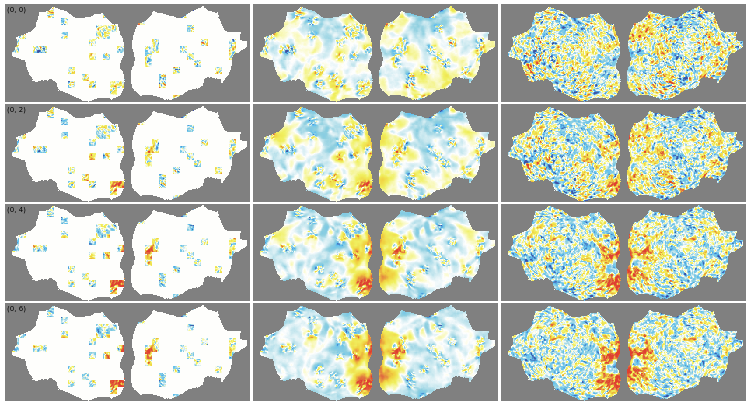

In [5]:
clip_idx = 16

plot_mask_pred(
    target=recons.images[:, :, clip_idx],
    pred=recons.pred_images[:, :, clip_idx],
    visible_mask=recons.visible_mask[:, :, clip_idx],
    pred_mask=recons.pred_mask[:, :, clip_idx],
    img_mask=recons.img_mask[:, :, clip_idx],
    nrow=4,
);

Compute model embeddings for the entire input. For this we'll use the Schaefer-400 parcellation based model.

In [6]:
model = CortexMAE.from_pretrained("cortex_mae_parcel").set_device()

The outputs have shape `(batch_size, clips, tokens, dim)` where
- `clips` = number of non-overlapping sliding windows to cover the full input
- `tokens` = ViT sequence length (4 temporal "patches" x 400 parcels)
- `dim` = ViT embedding dimension


In [7]:
embeds = model.run_embedding(path)

print(f"patch_embeds: {tuple(embeds.patch_embeds.shape)}")

patch_embeds: (1, 164, 1600, 768)


Many more pretrained models are available!

In [8]:
print("\n".join(list_models()))

cortex_mae_flat
cortex_mae_flat_r2
cortex_mae_flat_r3
cortex_mae_flat_r4
cortex_mae_flat_r5
cortex_mae_flat_r6
cortex_mae_flat_r7
cortex_mae_flat_r8
cortex_mae_volume
cortex_mae_volume_r2
cortex_mae_volume_r3
cortex_mae_volume_r4
cortex_mae_volume_r5
cortex_mae_volume_r6
cortex_mae_volume_r7
cortex_mae_volume_r8
cortex_mae_parcel
cortex_mae_parcel_r2
cortex_mae_parcel_r3
cortex_mae_parcel_r4
cortex_mae_parcel_r5
cortex_mae_parcel_r6
cortex_mae_parcel_r7
cortex_mae_parcel_r8
cortex_mae_a424
cortex_mae_a424_r2
cortex_mae_a424_r3
cortex_mae_a424_r4
cortex_mae_s400ts3
cortex_mae_s400ts3_r2
cortex_mae_s400ts3_r3
cortex_mae_s400ts3_r4
cortex_mae_flat_n100
cortex_mae_flat_n100_r2
cortex_mae_flat_n200
cortex_mae_flat_n200_r2
cortex_mae_flat_n400
cortex_mae_flat_n400_r2
cortex_mae_flat_n800
cortex_mae_flat_n800_r2
cortex_mae_flat_n1600
cortex_mae_flat_n1600_r2
cortex_mae_flat_d3
cortex_mae_flat_d3_r2
cortex_mae_flat_d6
cortex_mae_flat_d6_r2
cortex_mae_flat_d9
cortex_mae_flat_d9_r2
cortex_mae_fl